In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))
from scipy.optimize import curve_fit
from scipy import stats
import pandas as pd
from v1.Utils import ReadTheCsv,ReadTheSpill,append_to_dict

# Load simulation outputs

In [2]:
files = os.listdir("../toy/output/")
#print(files)

outputs = ["toy/output/" + item for item in files if ".npz" in item]
print(outputs)

simulation_list = {}

for output in outputs:
    filename   = output.split("/")[2]
    tau        = output.split("_")[1].replace("s","")
    theta      = output.split("_")[3]
    axial      = output.split("_")[5].replace("mK","")
    transverse = output.split("_")[5].replace("mK","")
    append_to_dict(simulation_list, output, float(tau))
    append_to_dict(simulation_list, output, float(theta))
    append_to_dict(simulation_list, output, float(axial))
    append_to_dict(simulation_list, output, float(transverse))

['toy/output/tau_25s_theta_25_axial_5.0mK_transv_8.0mK_p_2.npz', 'toy/output/tau_35s_theta_25_axial_8.0mK_transv_5.0mK_p_2.npz', 'toy/output/tau_30s_theta_10_axial_5.0mK_transv_4.0mK_p_2.npz', 'toy/output/tau_20s_theta_25_axial_6.0mK_transv_5.0mK_p_2.npz', 'toy/output/tau_20s_theta_14_axial_6.0mK_transv_8.0mK_p_2.npz', 'toy/output/tau_25s_theta_20_axial_4.0mK_transv_6.0mK_p_2.npz', 'toy/output/tau_30s_theta_20_axial_4.0mK_transv_5.0mK_p_2.npz', 'toy/output/tau_25s_theta_14_axial_5.0mK_transv_8.0mK_p_2.npz', 'toy/output/tau_15s_theta_25_axial_5.0mK_transv_8.0mK_p_2.npz', 'toy/output/tau_25s_theta_20_axial_5.0mK_transv_4.0mK_p_2.npz', 'toy/output/tau_30s_theta_20_axial_8.0mK_transv_4.0mK_p_2.npz', 'toy/output/tau_35s_theta_14_axial_5.0mK_transv_4.0mK_p_2.npz', 'toy/output/tau_35s_theta_14_axial_5.0mK_transv_6.0mK_p_2.npz', 'toy/output/tau_35s_theta_10_axial_5.0mK_transv_5.0mK_p_2.npz', 'toy/output/tau_15s_theta_14_axial_5.0mK_transv_6.0mK_p_2.npz', 'toy/output/tau_15s_theta_20_axial_5.0m

## Z cuts

In [3]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b, cuts):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a
        self.CutsType = cuts

ZCUTS = Zcuts(-415,-671, CutsType)

# Define the analysis functions for data and simulation

In [4]:
def analysis_function(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    Time_Annihilation = Time_Annihilation[np.isfinite(Time_Annihilation)]
    counts, edges = np.histogram(Time_Annihilation, bins = 50, range = (0,398.1), density = False)
    return Time_Annihilation, counts, edges

def analysis_data(file, Zcuts):
    # read the file
    dataset = ReadTheCsv(file, "-1", Zcuts.zmin, Zcuts.zmax, ZCUTS.CutsType)
    # Three Segment Ramp Down
    start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(file,"\"MBMF RampDown\"[0]")
    start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(file,"\"MBMF RampDown\"[1]")
    start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(file,"\"MBMF RampDown\"[2]")

    # print(f"{start_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]} ")
    # print(f"{start_mbmf_rampdown1[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown1[0] - start_mbmf_rampdown1[0]} ")
    # print(f"{start_mbmf_rampdown2[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown2[0] - start_mbmf_rampdown2[0]} ")
    mask      = ((dataset[CutsType] == 1) & 
                (dataset["Z"] > ZCUTS.zmin) & 
                (dataset["Z"] < ZCUTS.zmax))
    mask_time = ((dataset["run time"] > start_mbmf_rampdown0[0]) & 
                 (dataset["run time"] < start_mbmf_rampdown0[0] + 398.1))

    Event_Distribution = dataset["run time"][mask & mask_time].to_numpy() - start_mbmf_rampdown0[0]
    X_distribution = dataset["X"][mask & mask_time].to_numpy()
    Y_distribution = dataset["Y"][mask & mask_time].to_numpy()
    Z_distribution = dataset["Z"][mask & mask_time].to_numpy()

    counts, edges = np.histogram(Event_Distribution, bins = 50, range = (0,398.1), density = False)
    
    return Event_Distribution, counts, edges

# Main Loop LR statitics and visualization

In [5]:
!ls

Comparison.ipynb  simulation_results.png


In [6]:
# list_dataset = ["v1/ag14100/ag14100.vertex.csv",
#                 "v1/ag14106/ag14106.vertex.csv",
#                 "v1/ag14268/ag14268.vertex.csv",
#                 "v1/ag14286/ag14286.vertex.csv",
#                 "v1/ag14308/ag14308.vertex.csv"]

# best_for_dataset = []

# for dataset in list_dataset:
#     best_sim    = ""
#     best_LR     = 1e6
#     best_pvalue = 0.0

#     # read the dataset
#     Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    
#     for file in outputs:
#         Time_Simulation, counts_sim, edges_sim =  analysis_function("../" + file)

#         obs = Event_Distribution # time cut of the simulation :(
#         sim = Time_Simulation

#         counts_sim = counts_sim * counts_obs.sum() / counts_sim.sum()
        
#         LR, pvalue_lr = stats.power_divergence(counts_obs, counts_sim, lambda_="log-likelihood")
#         print(f"LR statistic = {LR:.4}/{(len(counts_obs) - 1)}")
#         print(f"p-value      = {pvalue_lr}")

#         if(LR < best_LR):
#             best_sim = file
#             best_pvalue = pvalue_lr
#             best_LR = LR
#             stringa = f"Best LR: {LR:.5}/49, pvalue = {pvalue_lr:.4}"
        
#         print(f"best pvalue {best_pvalue}")
#         print(f"best LR {best_LR}")
#         print("-"*16)
    
#     best_for_dataset.append((best_sim, stringa))

In [7]:
list_dataset = ["v1/ag14100/ag14100.vertex.csv",
                "v1/ag14106/ag14106.vertex.csv",
                "v1/ag14268/ag14268.vertex.csv",
                "v1/ag14286/ag14286.vertex.csv",
                "v1/ag14308/ag14308.vertex.csv"]

best_for_dataset = []
best_sim    = ""
stringa = ""

dict_runs = {}
for dataset in list_dataset:
    Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    append_to_dict(dict_runs, dataset, counts_obs)

best_LR     = 1e6
best_pvalue = 0.0

for file in outputs:
    LR_total    = 0
    Time_Simulation, counts_sim, edges_sim =  analysis_function("../" + file)
    
    for dataset in list_dataset:        
        counts_obs = dict_runs[dataset][0]
        counts_sim = counts_sim * counts_obs.sum() / counts_sim.sum()
        
        LR, pvalue_lr = stats.power_divergence(counts_obs, counts_sim, lambda_="log-likelihood")
        LR_total += LR
        print(f"LR statistic = {LR:.4}/{(len(counts_obs) - 1)}")
        print(f"p-value      = {pvalue_lr}")

    if not np.isfinite(LR_total):
        LR_total = 9999999
    
    if(LR_total < best_LR):
        print(f'New Best Found: [{file} {LR_total}]  [{best_sim} {best_LR}]')
        best_sim = file
        best_pvalue = pvalue_lr
        best_LR = LR_total
        stringa = f"Best LR: {LR_total:.5}/245, pvalue = {pvalue_lr:.4}"


    append_to_dict(simulation_list, file, LR_total)
    
    print(f"best pvalue {best_pvalue}")
    print(f"best LR {best_LR}")
    print("-"*16)

print(best_sim)
best_for_dataset.append((best_sim, stringa))

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)
/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: invalid value encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


LR statistic = 414.0/49
p-value      = 3.0551047451839477e-59
LR statistic = 553.2/49
p-value      = 1.5793830862044401e-86
LR statistic = 292.8/49
p-value      = 1.9058514701651793e-36
LR statistic = 262.7/49
p-value      = 5.365945023987738e-31
best pvalue 4.1499977773792083e-10
best LR 958.4729971673506
----------------
LR statistic = 292.7/49
p-value      = 1.9893201200762485e-36
LR statistic = 264.2/49
p-value      = 2.855058416864702e-31
LR statistic = 378.7/49
p-value      = 1.716942318406221e-52
LR statistic = 192.5/49
p-value      = 6.615413785038551e-19
LR statistic = 180.8/49
p-value      = 5.545190104328965e-17
best pvalue 4.1499977773792083e-10
best LR 958.4729971673506
----------------
LR statistic = 300.8/49
p-value      = 6.479202492423348e-38
LR statistic = 317.6/49
p-value      = 5.393274397639294e-41
LR statistic = 394.6/49
p-value      = 1.599376750919119e-55
LR statistic = 189.3/49
p-value      = 2.2584145496149102e-18
LR statistic = 217.8/49
p-value      = 3.73913

In [8]:
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][4])[:10]:
    print(f"{k}: LR = {v[4]}")

toy/output/tau_15s_theta_25_axial_5.0mK_transv_4.0mK_p_2.npz: LR = 818.213852467976
toy/output/tau_20s_theta_25_axial_4.0mK_transv_5.0mK_p_2.npz: LR = 826.3809845932974
toy/output/tau_15s_theta_20_axial_5.0mK_transv_4.0mK_p_2.npz: LR = 903.6687840737522
toy/output/tau_15s_theta_20_axial_4.0mK_transv_4.0mK_p_2.npz: LR = 908.1201195332849
toy/output/tau_15s_theta_20_axial_4.0mK_transv_5.0mK_p_2.npz: LR = 926.0158557939774
toy/output/tau_15s_theta_14_axial_4.0mK_transv_6.0mK_p_2.npz: LR = 950.5077675865625
toy/output/tau_25s_theta_20_axial_4.0mK_transv_6.0mK_p_2.npz: LR = 958.4729971673506
toy/output/tau_15s_theta_25_axial_4.0mK_transv_6.0mK_p_2.npz: LR = 959.2147918797992
toy/output/tau_15s_theta_25_axial_6.0mK_transv_4.0mK_p_2.npz: LR = 969.1992715195453
toy/output/tau_20s_theta_20_axial_4.0mK_transv_6.0mK_p_2.npz: LR = 971.3961470401539


[('toy/output/tau_15s_theta_25_axial_5.0mK_transv_4.0mK_p_2.npz', 'Best LR: 818.21/245, pvalue = 1.569e-05')]
../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF R

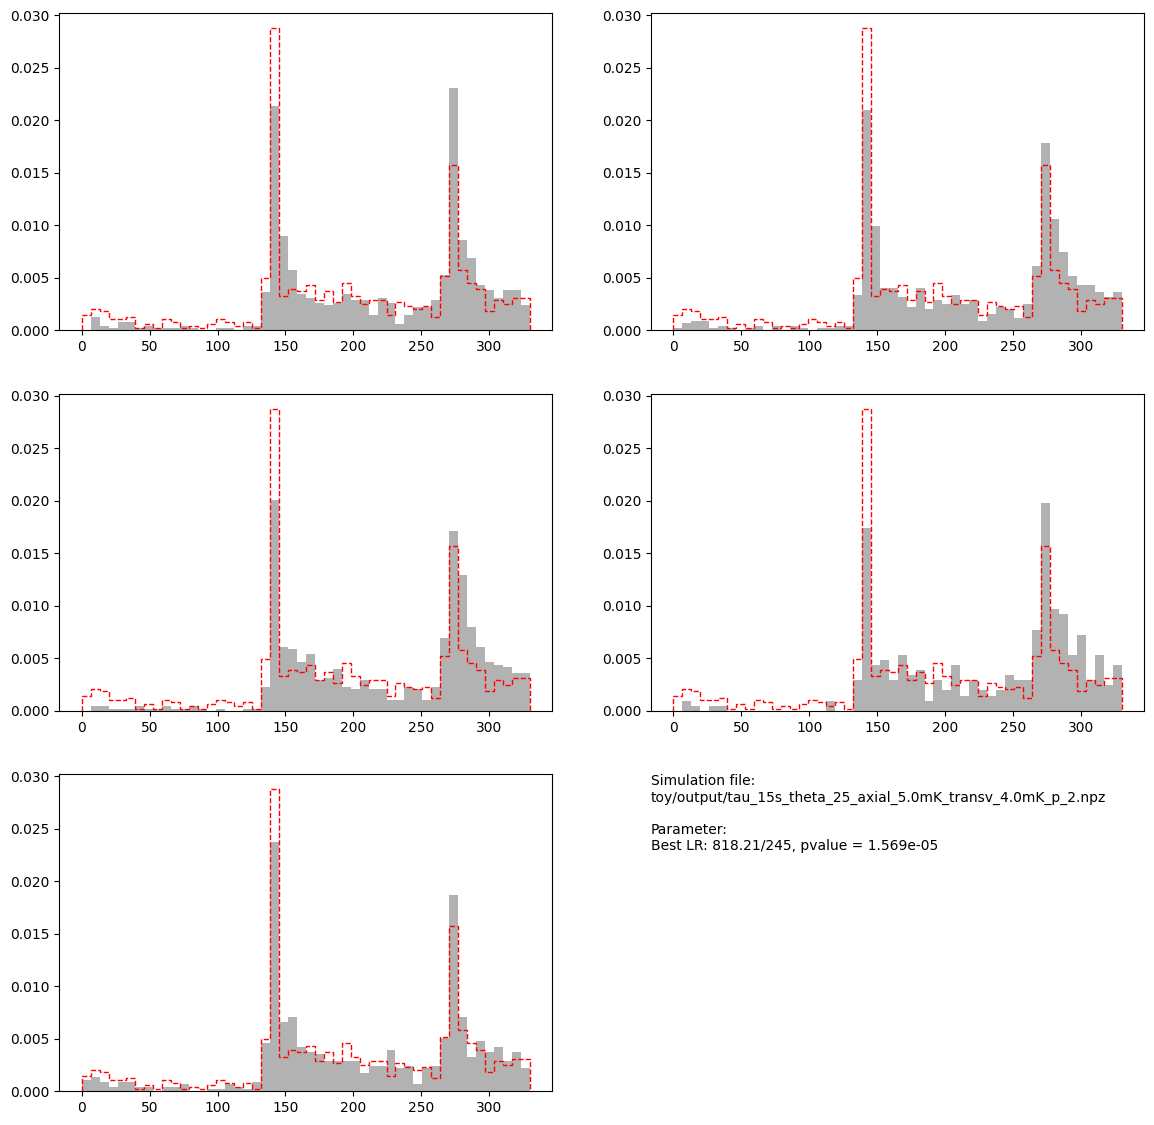

In [9]:
plt.figure(0, figsize=(14,14))

print(best_for_dataset)

i = 1
for dataset in list_dataset:
    simulation = best_for_dataset
    ax = plt.subplot(3, 2, i)
    i += 1

    Time_Simulation, counts, edges = analysis_function("../" + str(simulation[0][0]))
    Event_Distribution, counts, edges = analysis_data("../" + dataset, ZCUTS)

    ax.hist(Event_Distribution, bins=50, range=(0,330), density=True,
            color="black", alpha=.3)

    ax.hist(Time_Simulation, bins=50, range=(0,330), density=True,
            linestyle="--", histtype="step", color="red")

# ---- ultimo subplot SOLO TESTO ----
ax_text = plt.subplot(3, 2, 6)
ax_text.axis("off")   # niente assi

text = (
    f"Simulation file:\n"
    f"{simulation[0][0]}\n\n"
    f"Parameter:\n"
    f"{simulation[0][1]}"
)

ax_text.text(
    0.0, 1.0, text,
    transform=ax_text.transAxes,
    fontsize=10,
    verticalalignment="top"
)

plt.savefig("simulation_results.png", bbox_inches="tight")

# heatmap

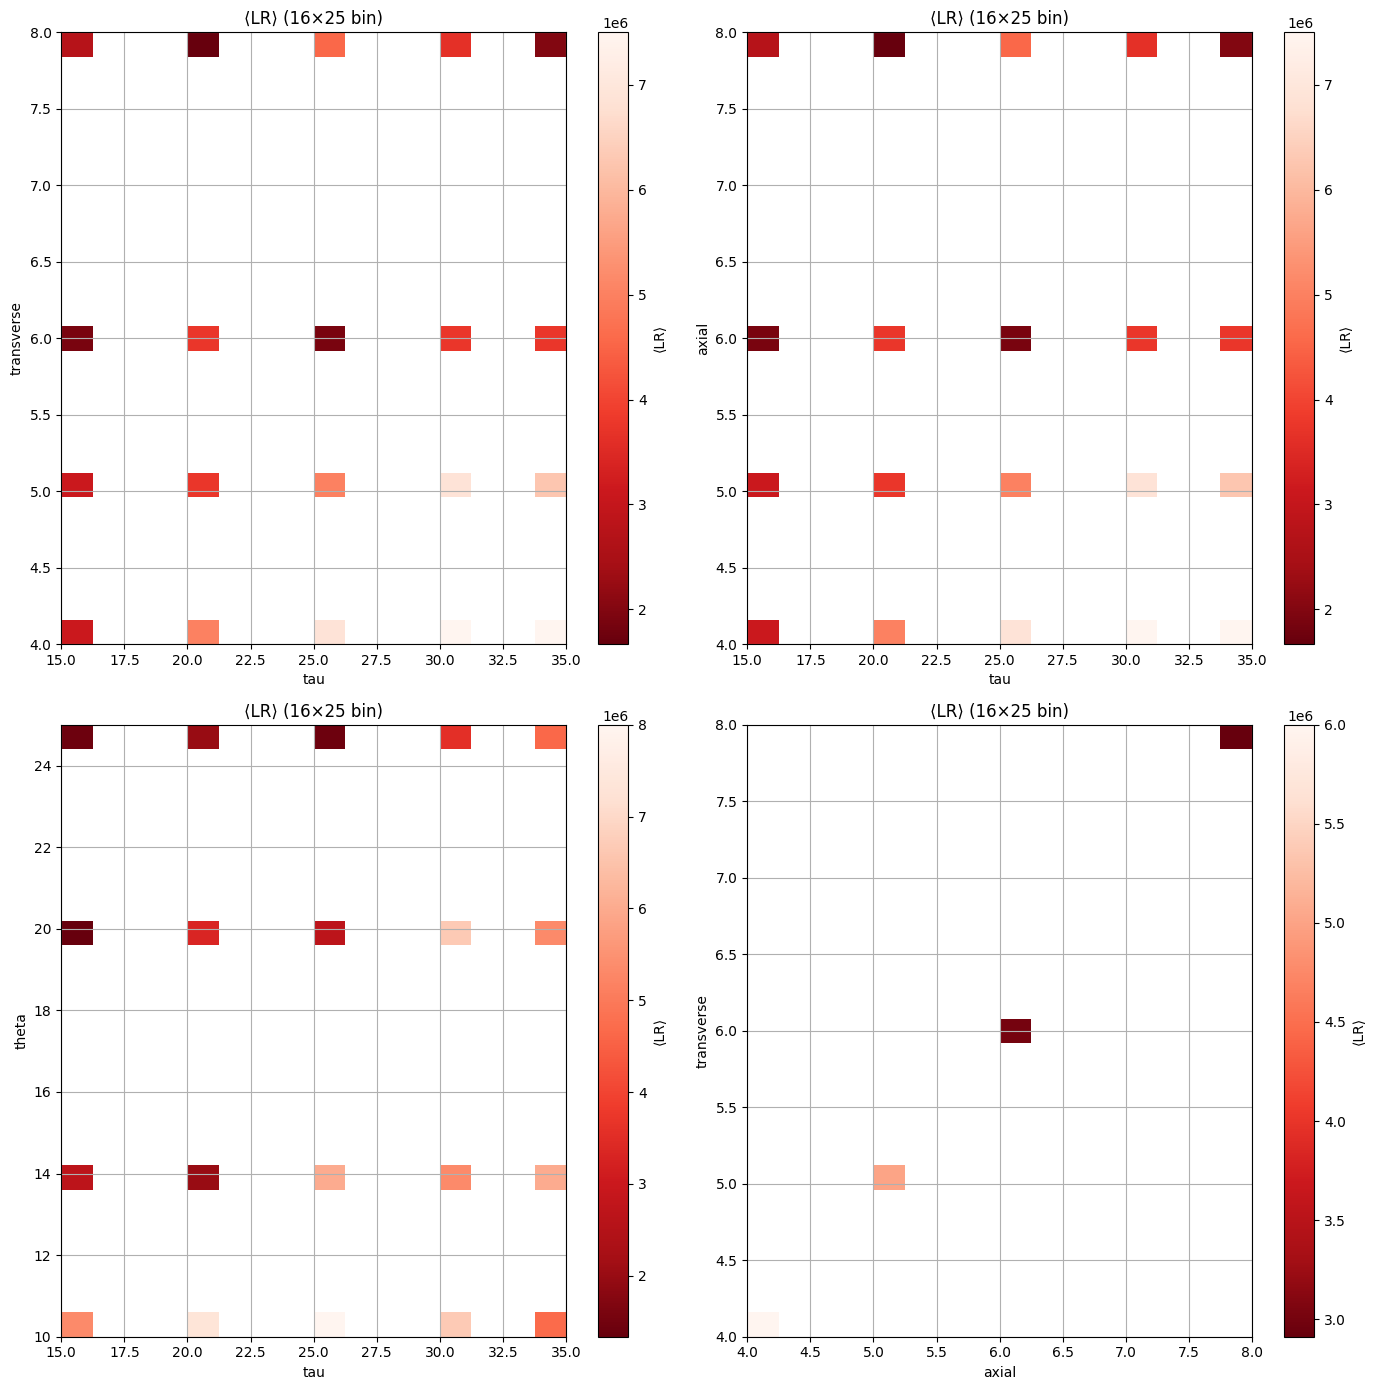

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# simulation_list = {
#     "file1.npz": [tau1, theta1, axial1, transverse1, LR1],
#     "file2.npz": [tau2, theta2, axial2, transverse2, LR2],
#     ...
# }

df = pd.DataFrame.from_dict(simulation_list, orient='index',
                            columns=["tau", "theta", "axial", "transverse", "LR"])


# Filtra il DataFrame per tau tra 0 e 40
df = df[(df["tau"] >= 0) & (df["tau"] <= 40)]

# Crea figura con 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Lista delle coppie di parametri da plottare
param_pairs = [
    ("tau", "transverse"),
    ("tau", "axial"),
    ("tau", "theta"),
    ("axial",   "transverse")
]

for i, (x_param, y_param) in enumerate(param_pairs):
    ax = axes[i // 2, i % 2]

    # estrai dati e rimuovi NaN
    mask = (
        np.isfinite(df[x_param]) &
        np.isfinite(df[y_param]) &
        np.isfinite(df["LR"])
    )

    x = df.loc[mask, x_param].values
    y = df.loc[mask, y_param].values
    z = df.loc[mask, "LR"].values

    # range fissi
    x_range = (x.min(), x.max())
    y_range = (y.min(), y.max())

    # binning
    LR_sum, xedges, yedges = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range],
        weights=z
    )

    counts, _, _ = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range]
    )

    # 🔴 FIX: inizializza LR_mean
    LR_mean = np.full_like(LR_sum, np.nan, dtype=float)
    LR_mean[counts != 0] = LR_sum[counts != 0] / counts[counts != 0]

    pcm = ax.pcolormesh(
        xedges,
        yedges,
        LR_mean.T,
        cmap="Reds_r",
        shading="auto"
    )

    ax.set_xlabel(x_param)
    ax.set_ylabel(y_param)
    ax.set_title("⟨LR⟩ (16×25 bin)")
    ax.grid(True)

    fig.colorbar(pcm, ax=ax, label="⟨LR⟩")

#axes[1, 1].axis("off")
plt.tight_layout()
plt.show()
